## MODULE4 --> TAE --> INTELIGENCIA ARTIFICIAL
    Professor: Dr Mario Valdovinos
    Student:   Cesar Eduardo Inda Ceniceros

# Utilizar con "Google Colab"

In [ ]:
# Google Colab-only setup — run this notebook in its own fresh Colab runtime.
import sys
if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This session 1 is Google Colab-only. Open https://colab.research.google.com/, "
        "upload this notebook, and run it there."
    )

%pip install -q ultralytics==8.4.102 matplotlib numpy pillow

import torch
torch.manual_seed(0)


# Utilizar con "Visual Studio Code"

In [ ]:
# Configuración compatible con VS Code/Jupyter
import sys
from pathlib import Path

print("Python:", sys.executable)
print("Carpeta de trabajo:", Path.cwd())

%pip install -q ultralytics==8.4.102 matplotlib numpy pillow

import torch
import ultralytics

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\tiori\.conda\envs\jupy\python.exe
Carpeta de trabajo: c:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos
Note: you may need to restart the kernel to use updated packages.
WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\tiori\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.7.1+cu118
Ultralytics: 8.4.102
Dispositivo: cuda
GPU: NVIDIA GeForce GTX 1050


In [ ]:
# Independent Colab assets — this notebook never reads another session's files.
from pathlib import Path
import os

SESSION_WORKSPACE = Path("/content/yolo_object_detection_session_01")
SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)
os.chdir(SESSION_WORKSPACE)

from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
settings.update({"datasets_dir": str(SESSION_DATASETS)})
COCO128_INFO = check_det_dataset("coco128.yaml", autodownload=True)
COCO128_YAML = Path(COCO128_INFO.get("yaml_file", "coco128.yaml"))
BASELINE_MODEL = YOLO("yolo11n.pt")  # Downloads and caches this notebook's pretrained weights.
print(f"Colab-only session 1: workspace={SESSION_WORKSPACE} | dataset={COCO128_YAML} | model=yolo11n.pt")



WARNING Dataset 'coco128.yaml' images not found, missing path 'C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets\coco128\images\train2017'
Unzipping C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets\coco128.zip to C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets\coco128...: 100% ━━━━━━━━━━━━ 263/263 450.3files/s 0.6s0.1s
Dataset download success  (2.3s), saved to C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets

Colab-only session 1: workspace=\content\yolo_object_detection_session_01 | dataset=C:\Users\tiori\.conda\envs\jupy\Lib\site-packages\ultralytics\cfg\datasets\coco128.yaml | model=yolo11n.pt


## 1. Record the environment

A result is easier to reproduce when its package version, checkpoint, device, and random seed are recorded.

In [ ]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version

import os
import random
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch

from PIL import Image, ImageDraw


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IS_COLAB = "google.colab" in sys.modules

CHECKPOINT = os.environ.get(
    "YOLO_CHECKPOINT",
    "yolo11n.pt"
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

try:
    ULTRALYTICS_VERSION = version("ultralytics")
    ULTRALYTICS_AVAILABLE = True
except PackageNotFoundError:
    ULTRALYTICS_VERSION = "not installed (fallback mode)"
    ULTRALYTICS_AVAILABLE = False

print({
    "seed": SEED,
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "ultralytics": ULTRALYTICS_VERSION,
    "checkpoint": CHECKPOINT,
    "device": DEVICE,
    "is_colab": IS_COLAB
})

{'seed': 42, 'python': '3.11.13', 'torch': '2.7.1+cu118', 'ultralytics': '8.4.102', 'checkpoint': 'yolo11n.pt', 'device': 'cuda', 'is_colab': False}


## 2. Inventory downloaded COCO128

COCO128 follows the Ultralytics detection layout: a dataset YAML names the classes and train split, `images/` holds photographs, and same-stem files under `labels/` hold one object per row. This notebook uses the downloaded COCO128 labels directly.

In [ ]:
# Use only the COCO128 copy downloaded by this notebook's Colab bootstrap.
YAML_PATH = COCO128_YAML
IMAGE_DIR = Path(COCO128_INFO["train"])
COCO_ROOT = Path(COCO128_INFO["path"])
relative_split = IMAGE_DIR.relative_to(COCO_ROOT / "images")
LABEL_DIR = COCO_ROOT / "labels" / relative_split
CLASS_NAMES = COCO128_INFO["names"]
if isinstance(CLASS_NAMES, list):
    CLASS_NAMES = dict(enumerate(CLASS_NAMES))
DATA_MODE = "COCO128 downloaded in this notebook"

print("Dataset mode:", DATA_MODE)
print("YAML:", YAML_PATH)
print("Images:", IMAGE_DIR)
print("Labels:", LABEL_DIR)
print("Classes:", CLASS_NAMES)
# Build only verified image–label pairs. COCO128 archives can contain orphan labels,
# so never derive an image path from a label without checking it exists first.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
image_by_stem = {path.stem: path for path in IMAGE_DIR.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES}
all_label_paths = sorted(LABEL_DIR.rglob("*.txt"))
label_paths = [path for path in all_label_paths if path.stem in image_by_stem]
missing_image_labels = [path for path in all_label_paths if path.stem not in image_by_stem]
image_paths = [image_by_stem[path.stem] for path in label_paths]
all_rows = []
for label_path in label_paths:
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if line.strip():
            all_rows.append((label_path, line_number, line.strip()))

print(f"Verified {len(image_paths)} image–label pairs; skipped {len(missing_image_labels)} orphan label file(s).")
print(f"Found {len(all_rows)} label rows in verified pairs.")
print("Three raw label examples:")
for path, line_number, row in all_rows[:3]:
    print(f"  {path.name}:{line_number}  {row}")
assert len(image_paths) >= 3 and len(all_rows) >= 3, "COCO128 download is incomplete."


Dataset mode: COCO128 downloaded in this notebook
YAML: C:\Users\tiori\.conda\envs\jupy\Lib\site-packages\ultralytics\cfg\datasets\coco128.yaml
Images: C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets\coco128\images\train2017
Labels: C:\Specialization_Artificial_Intelligence_Cinvestav\Module4_MarioValdovinos\datasets\coco128\labels\train2017
Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass',

In [ ]:
# Build only verified image–label pairs. COCO128 archives can contain orphan labels,
# so never derive an image path from a label without checking it exists first.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
image_by_stem = {path.stem: path for path in IMAGE_DIR.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES}
all_label_paths = sorted(LABEL_DIR.rglob("*.txt"))
label_paths = [path for path in all_label_paths if path.stem in image_by_stem]
missing_image_labels = [path for path in all_label_paths if path.stem not in image_by_stem]
image_paths = [image_by_stem[path.stem] for path in label_paths]
all_rows = []
for label_path in label_paths:
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if line.strip():
            all_rows.append((label_path, line_number, line.strip()))

print(f"Verified {len(image_paths)} image–label pairs; skipped {len(missing_image_labels)} orphan label file(s).")
print(f"Found {len(all_rows)} label rows in verified pairs.")
print("Three raw label examples:")
for path, line_number, row in all_rows[:3]:
    print(f"  {path.name}:{line_number}  {row}")
assert len(image_paths) >= 3 and len(all_rows) >= 3, "COCO128 download is incomplete."


Verified 126 image–label pairs; skipped 2 orphan label file(s).
Found 929 label rows in verified pairs.
Three raw label examples:
  000000000009.txt:1  45 0.479492 0.688771 0.955609 0.5955
  000000000009.txt:2  45 0.736516 0.247188 0.498875 0.476417
  000000000009.txt:3  50 0.637063 0.732938 0.494125 0.510583


## 3. Decode one label by hand

For a `640 × 480` image, consider `2 0.5 0.5 0.5 0.5`. The normalized center becomes `(320, 240)` pixels and the size becomes `(320, 240)` pixels. Half the width/height extends on each side, so the corners are `(160, 120, 480, 360)`. No `+1` is used because we treat boxes as half-open geometric rectangles.

In [ ]:
supplied = "2 0.5 0.5 0.5 0.5"
_, x_center_n, y_center_n, width_n, height_n = supplied.split()
W, H = 640, 480
x_center, y_center = float(x_center_n) * W, float(y_center_n) * H
box_width, box_height = float(width_n) * W, float(height_n) * H
hand_corners = (x_center-box_width/2, y_center-box_height/2, x_center+box_width/2, y_center+box_height/2)
print(f"center=({x_center:.0f}, {y_center:.0f}), size=({box_width:.0f}, {box_height:.0f})")
print("corners (x1, y1, x2, y2) =", hand_corners)
assert hand_corners == (160.0, 120.0, 480.0, 360.0)

center=(320, 240), size=(320, 240)
corners (x1, y1, x2, y2) = (160.0, 120.0, 480.0, 360.0)


## 4. Exercise E1 — convert normalized center-size to pixel corners

Complete the four equations. Keep floating-point corners: rounding is a separate display decision.

In [ ]:
# TODO: Return (x1, y1, x2, y2) in pixels from normalized center-size values.
# HINT: Multiply x/width quantities by image_width and y/height by image_height.

#!Done...
def yolo_to_xyxy(
    x_center_n,
    y_center_n,
    width_n,
    height_n,
    image_width,
    image_height
):
    """
    Convert normalized YOLO coordinates:
        (x_center, y_center, width, height)

    into pixel corner coordinates:
        (x1, y1, x2, y2)
    """

    x_center = float(x_center_n) * image_width
    y_center = float(y_center_n) * image_height

    box_width = float(width_n) * image_width
    box_height = float(height_n) * image_height

    x1 = x_center - box_width / 2
    y1 = y_center - box_height / 2
    x2 = x_center + box_width / 2
    y2 = y_center + box_height / 2

    return x1, y1, x2, y2

# Comprobación con el ejemplo de la celda anterior
test_box = yolo_to_xyxy(
    0.5, 0.5, 0.5, 0.5,
    image_width=640,
    image_height=480
)

print("Test box:", test_box)

assert test_box == (160.0, 120.0, 480.0, 360.0)


Test box: (160.0, 120.0, 480.0, 360.0)


## 5. Exercise E2 — validate before decoding

A decoder should fail loudly on bad annotations. Add checks for the five-field layout, class ID, finite normalized values, allowed range, and positive dimensions. A valid box is asserted to stay inside the image instead of being silently clipped.

In [ ]:
# TODO: Parse and validate one YOLO row, then return (class_id, x1, y1, x2, y2).
# HINT: Reject wrong field counts, invalid class IDs/ranges, non-finite values, and nonpositive sizes.

#!Done...

def decode_yolo_row(row, image_width, image_height, num_classes):
    """
    Parse and validate one YOLO annotation row.

    Expected format:
        class_id x_center y_center width height

    Returns:
        (class_id, x1, y1, x2, y2)
    """

    fields = row.split()

    assert len(fields) == 5, (
        f"Expected 5 fields, but received {len(fields)}: {row!r}"
    )

    class_text, x_text, y_text, width_text, height_text = fields

    # YOLO class identifiers must be integers.
    try:
        class_id = int(class_text)
    except ValueError as exc:
        raise AssertionError(
            f"Class ID must be an integer: {class_text!r}"
        ) from exc

    assert 0 <= class_id < num_classes, (
        f"Class ID {class_id} is outside the valid range "
        f"[0, {num_classes - 1}]"
    )

    try:
        x_center_n = float(x_text)
        y_center_n = float(y_text)
        width_n = float(width_text)
        height_n = float(height_text)
    except ValueError as exc:
        raise AssertionError(
            f"Coordinates must be numeric: {row!r}"
        ) from exc

    values = np.array(
        [x_center_n, y_center_n, width_n, height_n],
        dtype=float
    )

    assert np.all(np.isfinite(values)), (
        f"Coordinates must be finite numbers: {row!r}"
    )

    assert 0.0 <= x_center_n <= 1.0, (
        f"x_center must be between 0 and 1, received {x_center_n}"
    )

    assert 0.0 <= y_center_n <= 1.0, (
        f"y_center must be between 0 and 1, received {y_center_n}"
    )

    assert 0.0 < width_n <= 1.0, (
        f"width must be greater than 0 and at most 1, received {width_n}"
    )

    assert 0.0 < height_n <= 1.0, (
        f"height must be greater than 0 and at most 1, received {height_n}"
    )

    x1, y1, x2, y2 = yolo_to_xyxy(
        x_center_n,
        y_center_n,
        width_n,
        height_n,
        image_width,
        image_height
    )

    return class_id, x1, y1, x2, y2


In [ ]:
%pip install -q ultralytics

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path

from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import ROOT

# Archivo YAML incluido con Ultralytics.
COCO128_YAML = ROOT / "cfg" / "datasets" / "coco128.yaml"

assert COCO128_YAML.exists(), (
    f"No se encontró el archivo YAML: {COCO128_YAML}"
)

# Verifica y descarga automáticamente COCO128 si todavía no existe.
COCO128_INFO = check_det_dataset(
    str(COCO128_YAML),
    autodownload=True
)

print("COCO128 configurado correctamente")
print("YAML:", COCO128_YAML)
print("Dataset root:", COCO128_INFO["path"])
print("Train images:", COCO128_INFO["train"])
print("Number of classes:", len(COCO128_INFO["names"]))


WARNING Dataset 'C://Users/tiori/.conda/envs/jupy/Lib/site-packages/ultralytics/cfg/datasets/coco128.yaml' images not found, missing path 'C:\content\yolo_object_detection_session_01\datasets\coco128\images\train2017'
Unzipping \content\yolo_object_detection_session_01\datasets\coco128.zip to C:\content\yolo_object_detection_session_01\datasets\coco128...: 100% ━━━━━━━━━━━━ 263/263 642.2files/s 0.4s0.0s
Dataset download success  (2.0s), saved to \content\yolo_object_detection_session_01\datasets

COCO128 configurado correctamente
YAML: C:\Users\tiori\.conda\envs\jupy\Lib\site-packages\ultralytics\cfg\datasets\coco128.yaml
Dataset root: C:\content\yolo_object_detection_session_01\datasets\coco128
Train images: C:\content\yolo_object_detection_session_01\datasets\coco128\images\train2017
Number of classes: 80


In [6]:
from pathlib import Path

from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import ROOT


# ============================================================
# 1. Locate the COCO128 YAML included with Ultralytics
# ============================================================

COCO128_YAML = (
    Path(ROOT)
    / "cfg"
    / "datasets"
    / "coco128.yaml"
)

assert COCO128_YAML.exists(), (
    f"No se encontró el archivo YAML de COCO128:\n"
    f"{COCO128_YAML}"
)


# ============================================================
# 2. Validate or download COCO128
# ============================================================

COCO128_INFO = check_det_dataset(
    str(COCO128_YAML),
    autodownload=True
)


# ============================================================
# 3. Configure dataset paths
# ============================================================

YAML_PATH = COCO128_YAML
COCO_ROOT = Path(COCO128_INFO["path"])
IMAGE_DIR = Path(COCO128_INFO["train"])

relative_split = IMAGE_DIR.relative_to(
    COCO_ROOT / "images"
)

LABEL_DIR = (
    COCO_ROOT
    / "labels"
    / relative_split
)

CLASS_NAMES = COCO128_INFO["names"]

if isinstance(CLASS_NAMES, list):
    CLASS_NAMES = dict(enumerate(CLASS_NAMES))

DATA_MODE = "COCO128 downloaded in this notebook"


# ============================================================
# 4. Show configuration
# ============================================================

print("Dataset mode:", DATA_MODE)
print("YAML:", YAML_PATH)
print("Dataset root:", COCO_ROOT)
print("Images:", IMAGE_DIR)
print("Labels:", LABEL_DIR)
print("Number of classes:", len(CLASS_NAMES))


# ============================================================
# 5. Verify paths
# ============================================================

assert COCO_ROOT.exists(), (
    f"No existe la raíz del dataset: {COCO_ROOT}"
)

assert IMAGE_DIR.exists(), (
    f"No existe el directorio de imágenes: {IMAGE_DIR}"
)

assert LABEL_DIR.exists(), (
    f"No existe el directorio de etiquetas: {LABEL_DIR}"
)

print("\nCOCO128 configured successfully.")

Dataset mode: COCO128 downloaded in this notebook
YAML: C:\Users\tiori\.conda\envs\jupy\Lib\site-packages\ultralytics\cfg\datasets\coco128.yaml
Dataset root: C:\content\yolo_object_detection_session_01\datasets\coco128
Images: C:\content\yolo_object_detection_session_01\datasets\coco128\images\train2017
Labels: C:\content\yolo_object_detection_session_01\datasets\coco128\labels\train2017
Number of classes: 80

COCO128 configured successfully.


In [7]:
# Build verified image–label pairs.

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

image_by_stem = {
    path.stem: path
    for path in IMAGE_DIR.rglob("*")
    if path.suffix.lower() in IMAGE_SUFFIXES
}

all_label_paths = sorted(LABEL_DIR.rglob("*.txt"))

label_paths = [
    path
    for path in all_label_paths
    if path.stem in image_by_stem
]

missing_image_labels = [
    path
    for path in all_label_paths
    if path.stem not in image_by_stem
]

image_paths = [
    image_by_stem[path.stem]
    for path in label_paths
]

all_rows = []

for label_path in label_paths:
    lines = label_path.read_text(
        encoding="utf-8"
    ).splitlines()

    for line_number, line in enumerate(lines, start=1):
        row = line.strip()

        if row:
            all_rows.append(
                (label_path, line_number, row)
            )

print(
    f"Verified {len(image_paths)} image–label pairs; "
    f"skipped {len(missing_image_labels)} orphan label file(s)."
)

print(
    f"Found {len(all_rows)} label rows in verified pairs."
)

print("Three raw label examples:")

for path, line_number, row in all_rows[:3]:
    print(f"  {path.name}:{line_number}  {row}")

assert len(image_paths) >= 3, (
    "No se encontraron suficientes imágenes."
)

assert len(all_rows) >= 3, (
    "No se encontraron suficientes anotaciones."
)

Verified 126 image–label pairs; skipped 2 orphan label file(s).
Found 929 label rows in verified pairs.
Three raw label examples:
  000000000009.txt:1  45 0.479492 0.688771 0.955609 0.5955
  000000000009.txt:2  45 0.736516 0.247188 0.498875 0.476417
  000000000009.txt:3  50 0.637063 0.732938 0.494125 0.510583


In [15]:
import math


def yolo_to_xyxy(
    x_center_n,
    y_center_n,
    width_n,
    height_n,
    image_width,
    image_height
):
    """
    Convert normalized YOLO coordinates to pixel corners.

    Input:
        x_center_n, y_center_n, width_n, height_n

    Output:
        x1, y1, x2, y2
    """

    x_center = x_center_n * image_width
    y_center = y_center_n * image_height

    box_width = width_n * image_width
    box_height = height_n * image_height

    x1 = x_center - box_width / 2
    y1 = y_center - box_height / 2
    x2 = x_center + box_width / 2
    y2 = y_center + box_height / 2

    return x1, y1, x2, y2


def decode_yolo_row(
    row,
    image_width,
    image_height,
    num_classes
):
    """
    Parse and validate one YOLO annotation row.

    Expected format:
        class_id x_center y_center width height

    Returns:
        class_id, x1, y1, x2, y2
    """

    fields = row.strip().split()

    # A YOLO detection row must contain exactly five fields.
    assert len(fields) == 5, (
        f"Expected 5 fields, received {len(fields)}: {row!r}"
    )

    class_text, x_text, y_text, width_text, height_text = fields

    # Validate class identifier.
    try:
        class_id = int(class_text)
    except ValueError as exc:
        raise AssertionError(
            f"Class ID must be an integer, received {class_text!r}"
        ) from exc

    assert 0 <= class_id < num_classes, (
        f"Class ID {class_id} is outside the valid range "
        f"[0, {num_classes - 1}]"
    )

    # Convert normalized coordinates.
    try:
        x_center_n = float(x_text)
        y_center_n = float(y_text)
        width_n = float(width_text)
        height_n = float(height_text)
    except ValueError as exc:
        raise AssertionError(
            f"Coordinates must be numeric: {row!r}"
        ) from exc

    normalized_values = (
        x_center_n,
        y_center_n,
        width_n,
        height_n
    )

    # Reject NaN and infinity.
    assert all(math.isfinite(value) for value in normalized_values), (
        f"Coordinates must be finite: {row!r}"
    )

    # Validate normalized coordinate ranges.
    assert 0.0 <= x_center_n <= 1.0, (
        f"x_center must be between 0 and 1, received {x_center_n}"
    )

    assert 0.0 <= y_center_n <= 1.0, (
        f"y_center must be between 0 and 1, received {y_center_n}"
    )

    assert 0.0 < width_n <= 1.0, (
        f"width must be greater than 0 and at most 1, "
        f"received {width_n}"
    )

    assert 0.0 < height_n <= 1.0, (
        f"height must be greater than 0 and at most 1, "
        f"received {height_n}"
    )

    # Convert normalized values to pixel coordinates.
    x1, y1, x2, y2 = yolo_to_xyxy(
        x_center_n=x_center_n,
        y_center_n=y_center_n,
        width_n=width_n,
        height_n=height_n,
        image_width=image_width,
        image_height=image_height
    )

    return class_id, x1, y1, x2, y2


print("Functions defined successfully.")

Functions defined successfully.


In [16]:
from PIL import Image

# Audit every nonempty label row programmatically.
for label_path, line_number, row in all_rows:
    image_path = image_by_stem[label_path.stem]

    with Image.open(image_path) as image:
        decode_yolo_row(
            row,
            image.width,
            image.height,
            len(CLASS_NAMES)
        )

print(f"Validated all {len(all_rows)} rows.")


# Malformed examples should trigger clear assertions.
malformed = {
    "wrong field count": "0 0.5 0.5 0.2",
    "invalid class": (
        f"{len(CLASS_NAMES)} 0.5 0.5 0.2 0.2"
    ),
    "range error": "0 1.2 0.5 0.2 0.2",
    "nonpositive width": "0 0.5 0.5 0.0 0.2",
}

for description, row in malformed.items():
    try:
        decode_yolo_row(
            row,
            640,
            480,
            len(CLASS_NAMES)
        )

        raise RuntimeError(
            f"Malformed row unexpectedly passed: {description}"
        )

    except AssertionError as error:
        print(f"Caught {description}: {error}")

Validated all 929 rows.
Caught wrong field count: Expected 5 fields, received 4: '0 0.5 0.5 0.2'
Caught invalid class: Class ID 80 is outside the valid range [0, 79]
Caught range error: x_center must be between 0 and 1, received 1.2
Caught nonpositive width: width must be greater than 0 and at most 1, received 0.0


## 6. Visualize three ground-truth label sets

The picture is the final geometry check. A mathematically valid box can still surround the wrong object if files were paired incorrectly.

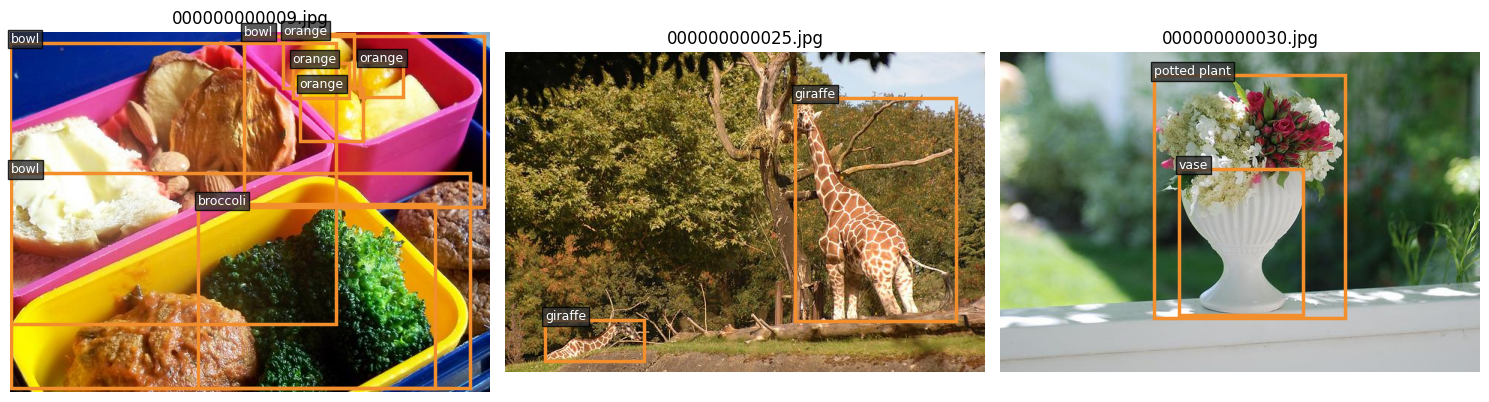

In [18]:
import matplotlib.pyplot as plt

def matching_label_path(image_path):
    return LABEL_DIR / f"{image_path.stem}.txt"

def ground_truth_for(image_path):
    with Image.open(image_path) as opened:
        width, height = opened.size
    label_path = matching_label_path(image_path)
    rows = label_path.read_text(encoding="utf-8").splitlines() if label_path.exists() else []
    return [decode_yolo_row(row, width, height, len(CLASS_NAMES)) for row in rows if row.strip()]

selected_images = [path for path in image_paths if matching_label_path(path).exists()][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, image_path in zip(axes, selected_images):
    image = Image.open(image_path).convert("RGB")
    axis.imshow(image); axis.set_title(image_path.name); axis.axis("off")
    for class_id, x1, y1, x2, y2 in ground_truth_for(image_path):
        axis.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="#f28e2b", lw=2.5))
        axis.text(x1, y1, CLASS_NAMES[class_id], color="white", fontsize=9,
                  bbox={"facecolor": "#333333", "alpha": 0.8, "pad": 2})
plt.tight_layout()

In [20]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version

import os
import sys

import numpy as np
import torch

from PIL import Image, ImageDraw


# ============================================================
# Inference configuration
# ============================================================

IS_COLAB = "google.colab" in sys.modules

CHECKPOINT = os.environ.get(
    "YOLO_CHECKPOINT",
    "yolo11n.pt"
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# Check whether Ultralytics is installed.
try:
    ULTRALYTICS_VERSION = version("ultralytics")
    ULTRALYTICS_AVAILABLE = True
except PackageNotFoundError:
    ULTRALYTICS_VERSION = "not installed"
    ULTRALYTICS_AVAILABLE = False


print({
    "checkpoint": CHECKPOINT,
    "checkpoint_exists": Path(CHECKPOINT).expanduser().exists(),
    "device": DEVICE,
    "ultralytics_available": ULTRALYTICS_AVAILABLE,
    "ultralytics_version": ULTRALYTICS_VERSION,
    "is_colab": IS_COLAB
})

{'checkpoint': 'yolo11n.pt', 'checkpoint_exists': False, 'device': 'cuda', 'ultralytics_available': True, 'ultralytics_version': '8.4.102', 'is_colab': False}


## 7. Run pretrained inference on the same images

A detection is one `(class, confidence, xyxy)` record. The number of records may differ across images—even zero is valid. In fallback mode, deterministic pseudo-predictions keep the output contract visible; they are **not** model results.

In [21]:
CONFIDENCE_THRESHOLD = 0.25
checkpoint_path = Path(CHECKPOINT).expanduser()
REAL_INFERENCE = ULTRALYTICS_AVAILABLE and (IS_COLAB or checkpoint_path.exists())

if REAL_INFERENCE:
    from ultralytics import YOLO
    model = YOLO(CHECKPOINT)
    raw_results = model.predict([str(path) for path in selected_images], conf=CONFIDENCE_THRESHOLD, device=DEVICE, verbose=False)
    prediction_rows = []
    rendered_images = []
    for image_path, result in zip(selected_images, raw_results):
        rows = []
        for box in result.boxes:
            class_id = int(box.cls.item())
            confidence = float(box.conf.item())
            corners = tuple(float(value) for value in box.xyxy[0].tolist())
            rows.append((result.names[class_id], confidence, corners))
        prediction_rows.append(rows)
        rendered_images.append(result.plot()[..., ::-1])  # Ultralytics BGR -> RGB
    INFERENCE_MODE = f"Ultralytics {ULTRALYTICS_VERSION}, {CHECKPOINT}"
else:
    prediction_rows = []
    rendered_images = []
    for image_path in selected_images:
        image = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        rows = []
        for index, (class_id, x1, y1, x2, y2) in enumerate(ground_truth_for(image_path)):
            # Fixed offsets make a visible, reproducible label/prediction disagreement.
            dx, dy = 5 + 2*index, 3 + index
            corners = (x1+dx, y1+dy, x2+dx, y2+dy)
            confidence = 0.88 - 0.09*index
            rows.append((CLASS_NAMES[class_id], confidence, corners))
            draw.rectangle(corners, outline=(170, 40, 40), width=3)
            draw.text((corners[0], max(0, corners[1]-12)), f"{CLASS_NAMES[class_id]} {confidence:.2f}", fill=(120, 0, 0))
        prediction_rows.append(rows)
        rendered_images.append(np.asarray(image))
    INFERENCE_MODE = "deterministic pseudo-predictions (offline validation only)"

print("Inference mode:", INFERENCE_MODE)
print("Confidence threshold:", CONFIDENCE_THRESHOLD)
for image_path, rows in zip(selected_images, prediction_rows):
    print(f"\n{image_path.name}: {len(rows)} detection(s)")
    for class_name, confidence, corners in rows:
        rounded = tuple(round(value, 1) for value in corners)
        print(f"  class={class_name:<12} confidence={confidence:.3f} xyxy={rounded}")

Inference mode: deterministic pseudo-predictions (offline validation only)
Confidence threshold: 0.25

000000000009.jpg: 8 detection(s)
  class=bowl         confidence=0.880 xyxy=(6.1, 190.7, 617.7, 476.5)
  class=bowl         confidence=0.790 xyxy=(318.7, 8.3, 638.0, 237.0)
  class=broccoli     confidence=0.700 xyxy=(258.6, 234.3, 574.8, 479.4)
  class=bowl         confidence=0.610 xyxy=(11.0, 19.5, 445.5, 394.6)
  class=orange       confidence=0.520 xyxy=(389.2, 47.4, 464.8, 93.9)
  class=orange       confidence=0.430 xyxy=(480.8, 47.0, 538.8, 93.6)
  class=orange       confidence=0.340 xyxy=(402.7, 82.7, 486.7, 153.2)
  class=orange       confidence=0.250 xyxy=(383.0, 12.5, 477.8, 83.6)

000000000025.jpg: 2 detection(s)
  class=giraffe      confidence=0.880 xyxy=(390.5, 63.0, 605.5, 360.2)
  class=giraffe      confidence=0.790 xyxy=(60.0, 360.5, 192.0, 415.7)

000000000030.jpg: 2 detection(s)
  class=potted plant confidence=0.880 xyxy=(209.9, 34.0, 464.7, 358.1)
  class=vase        

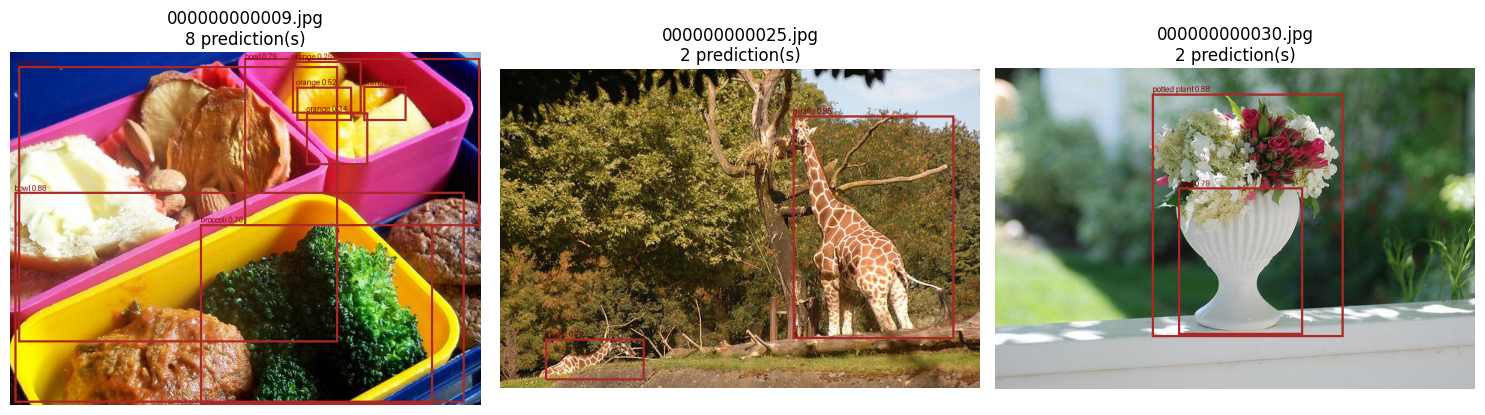

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, image_path, rendered in zip(axes, selected_images, rendered_images):
    axis.imshow(rendered); axis.set_title(f"{image_path.name}\n{len(prediction_rows[axes.tolist().index(axis)])} prediction(s)"); axis.axis("off")
plt.tight_layout()

## 8. Compare the three tasks

Describe their outputs and annotation types, not just their applications.

> TODO: Write exactly three sentences: one each for classification, semantic segmentation, and detection.
    
    
    La clasificación produce una sola clase o un vector de probabilidades para representar el contenido general de una imagen y utiliza una etiqueta global por imagen.  
    La segmentación semántica produce una clase para cada píxel y utiliza máscaras de anotación que delimitan las regiones correspondientes a cada categoría.  
    La detección de objetos produce una cantidad variable de cajas delimitadoras con su clase y confianza, y utiliza anotaciones formadas por una clase y las coordenadas de cada objeto.


## 9. Exercise E3 — explain one disagreement

Compare one label and prediction. Do not declare either one wrong before checking the image, annotation policy, threshold, class mapping, and localization evidence.

> TODO: Explain one label/prediction disagreement in 2–3 evidence-aware sentences.

    En una de las imágenes, la caja predicha no coincide exactamente con la caja de la anotación, ya que presenta un pequeño desplazamiento en sus esquinas. 
    Antes de considerar incorrecta la predicción, se debe revisar visualmente qué caja representa mejor los límites del objeto, 
    además de comprobar la política de anotación, el mapeo de clases y el umbral de confianza utilizado.

## Wrap-up

You audited YOLO's five-field annotation format, converted normalized center-size values to pixel corners, rejected malformed rows, visualized three ground-truth examples, and inspected variable-length detection records. The central habit is simple: **check the label language visually before interpreting model behavior**.

**Concept check:** Why is `0.5` a different geometric quantity in the second, fourth, and fifth fields of `2 0.5 0.5 0.5 0.5`?

    El segundo campo `0.5` representa la posición horizontal normalizada del centro de la caja, por lo que indica que el centro se encuentra al 50 % del ancho de la imagen.   
    El cuarto campo `0.5` representa que la caja ocupa el 50 % del ancho de la imagen, mientras que el quinto campo `0.5` indica que ocupa el 50 % de la altura. Aunque tienen el mismo valor numérico, representan posición horizontal, tamaño horizontal y tamaño vertical, respectivamente.